# Notebook 02 — Classical pipeline: before and after Bayesian optimisation

**Purpose.** This notebook walks through the classical ecDNA detection pipeline step by step on the anchor image, shows how Bayesian optimisation (BO) changed the per-cell-line parameters, and summarises the resulting gain in object-level F1 on the held-out test split.

**Audience.** A reviewer or collaborator who wants to understand how the classical pipeline works, what each preprocessing step does visually, and why BO was needed rather than hand-tuning.

**What this notebook produces** (all files written to `release/figures/notebook02/`):

| File | Description |
|------|-------------|
| `fig3_pipeline_schematic.svg` | Text-based pipeline flowchart |
| `fig3_preproc_steps.svg` | Preprocessing chain on the anchor inset |
| `fig3_preproc_steps_composite.svg` | Preprocessing chain — full frame + matched inset |
| `fig3_detection_steps.svg` | Detection, morphological close, merge, and HSV filter |
| `fig3_before_after_bo_overlay.svg` | Before/after BO predictions overlaid on the anchor |
| `fig3_bo_trajectories_simplified.svg` | Stage-3 BO running-best validation F1 per cell line |
| `fig3_bo_before_after_summary.svg` | Three-panel benchmark summary (overall, splits, density) |
| `fig3_before_after_f1_by_cell_line.svg` | Test F1 per cell line, before vs after BO |
| `fig3_frozen_params_table.svg` | Final frozen classical parameters per cell line |

**Quantitative provenance.** Aggregate benchmark numbers come from a dedicated two-model classical benchmark in `outputs/classical_bfr_aft/or_matching/` (Classic before opt vs Classic after opt). BO trajectories come from `outputs/classical_opt/partials/stage3/`. Frozen parameters come from `configs/classical/stage3_frozen_params.json`. The only operations recomputed live are (i) the classical pipeline applied to the anchor image in §3–§5, which exists for didactic purposes and is matched against GS inside the notebook, and (ii) trivial F1 aggregation from per-image TP/FP/FN.


In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import cv2
from IPython.display import display

# ── Repo root ───────────────────────────────────────────────────────────────
REPO_ROOT = Path(os.getcwd()).parent
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path(os.getcwd())
print(f'Repo root: {REPO_ROOT}')

for p in [REPO_ROOT / 'src', REPO_ROOT]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# ── Paths ───────────────────────────────────────────────────────────────────
# Longleaf path used for the paper run.
# For reviewer reproduction, replace this with the value from configs/paths.local.yaml.
DATA_ROOT = Path('/work/users/b/e/behnamie/ecDNA_Data/bioimage_archive')
RGB_DIR   = DATA_ROOT / 'rgb'
GT_DIR    = DATA_ROOT / 'gt_image'
ROI_DIR   = DATA_ROOT / 'roi_mask'

MANIFESTS  = REPO_ROOT / 'release' / 'manifests'
SPLIT_DIR  = REPO_ROOT / 'release' / 'split_files'
FROZEN_OR  = REPO_ROOT / 'release' / 'frozen_results' / 'or_matching'

# Classical configs and BO outputs
FROZEN_PARAMS_JSON      = REPO_ROOT / 'configs' / 'classical' / 'stage3_frozen_params.json'
DEFAULT_PARAMS_JSON     = REPO_ROOT / 'configs' / 'classical' / 'default_before_opt_frozen_params.json'
BO_PARTIALS_DIR         = REPO_ROOT / 'outputs' / 'classical_opt' / 'partials' / 'stage3'

FULL_META_CSV  = DATA_ROOT / 'metadata_internal.csv'
COUNTS_CSV     = MANIFESTS / 'counts_master.csv'

# Output directory
OUT_DIR = REPO_ROOT / 'release' / 'figures' / 'notebook02'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'SVG output: {OUT_DIR}')

# ── Anchor image ────────────────────────────────────────────────────────────
ANCHOR_UID        = 'ncih2170_facs_fish_0723_low_her2_52'
ANCHOR_INSET_BBOX = [1247, 1225, 1458, 1353]   # x0, y0, x1, y1

# ── Palettes ────────────────────────────────────────────────────────────────
CELL_LINE_COLORS = {
    'NCI-H2170': '#E69F00',
    'SUM159PT':  '#56B4E9',
    'SNU16':     '#009E73',
    'COLO320DM': '#CC79A7',
    'NCI-H716':  '#0072B2',
}
CL_ORDER = ['NCI-H2170', 'SNU16', 'COLO320DM', 'NCI-H716']

# ── Publication style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':         7,
    'axes.titlesize':    8,
    'axes.labelsize':    7,
    'xtick.labelsize':   6.2,
    'ytick.labelsize':   6.2,
    'legend.fontsize':   6.2,
    'figure.titlesize':  8,
    'axes.linewidth':    0.8,
    'lines.linewidth':   1.2,
    'savefig.dpi':       300,
    'svg.fonttype':      'none',
    'pdf.fonttype':      42,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

def save_fig(fig, name):
    svg_path = OUT_DIR / f'{name}.svg'
    png_path = OUT_DIR / f'{name}.png'
    fig.savefig(svg_path, format='svg', bbox_inches='tight')
    fig.savefig(png_path, format='png', dpi=150, bbox_inches='tight')
    print(f'  Saved: {svg_path.name}')

# ── Cell-line name normaliser (same as notebook 01) ─────────────────────────
def canonical_cell_line(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper().replace('-','').replace('_','').replace(' ','')
    return {'NCIH2170':'NCI-H2170','SUM159PT':'SUM159PT','SNU16':'SNU16',
            'COLO320DM':'COLO320DM','NCIH716':'NCI-H716'}.get(s, str(x).strip())

print('Setup complete.')

Repo root: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench
SVG output: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook02
Setup complete.


## §1 — Pipeline architecture

The classical ecDNA detection pipeline is a fully deterministic, parameter-driven
image-analysis chain. It has no learned components and runs in a few seconds per
image on a single CPU core.

The pipeline has four stages:

1. **Grayscale conversion** — channel-wise maximum projection preserves the
   brightest fluorescent signal regardless of which channel carries it.
2. **Preprocessing chain** — a fixed sequence of 3–4 enhancement operators
   (selected per cell line by Stage-1 exhaustive search), applied with
   parameters tuned by BO.
3. **Detection** — Otsu thresholding with a scale factor, morphological closing,
   8-connected-component extraction with min/max area filters, and a
   centroid-distance merge to collapse over-segmented blobs.
4. **HSV classification** — each detected object is classified as ecDNA or
   chromosome-like by testing its mean HSV value and saturation against
   per-cell-line thresholds. Only ecDNA-classified objects are counted.

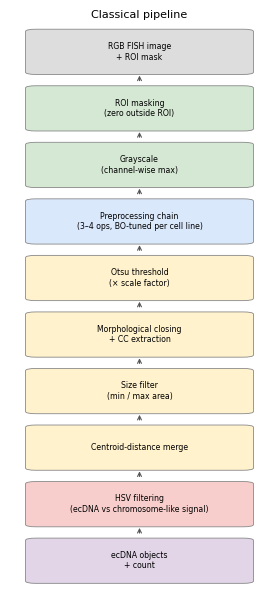

  Saved: fig3_pipeline_schematic.svg


In [2]:
# ── Fig 3A: Pipeline schematic as a text-based flowchart ────────────────────
# Pure matplotlib — no image dependencies.

stages = [
    ('RGB FISH image\n+ ROI mask', '#DDDDDD'),
    ('ROI masking\n(zero outside ROI)', '#D5E8D4'),
    ('Grayscale\n(channel-wise max)', '#D5E8D4'),
    ('Preprocessing chain\n(3–4 ops, BO-tuned per cell line)', '#DAE8FC'),
    ('Otsu threshold\n(× scale factor)', '#FFF2CC'),
    ('Morphological closing\n+ CC extraction', '#FFF2CC'),
    ('Size filter\n(min / max area)', '#FFF2CC'),
    ('Centroid-distance merge', '#FFF2CC'),
    ('HSV filtering\n(ecDNA vs chromosome-like signal)', '#F8CECC'),
    ('ecDNA objects\n+ count', '#E1D5E7'),
]

# Save schematic source data for reproducibility
pd.DataFrame(stages, columns=['stage', 'color']).to_csv(
    OUT_DIR / 'fig3_pipeline_schematic_source.csv',
    index=False
)

fig, ax = plt.subplots(figsize=(2.8, 6.0))
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, len(stages) - 0.5)
ax.axis('off')

box_h = 0.72
box_w = 0.80
x0 = 0.10

for i, (label, color) in enumerate(stages):
    y = len(stages) - 1 - i

    rect = mpatches.FancyBboxPatch(
        (x0, y - box_h / 2), box_w, box_h,
        boxstyle='round,pad=0.04',
        facecolor=color,
        edgecolor='#888888',
        linewidth=0.6,
    )
    ax.add_patch(rect)

    ax.text(
        x0 + box_w / 2, y, label,
        ha='center',
        va='center',
        fontsize=5.6,
        linespacing=1.2,
    )

    if i < len(stages) - 1:
        y_arrow = y - box_h / 2
        ax.annotate(
            '',
            xy=(0.5, y_arrow - 0.01),
            xytext=(0.5, y_arrow - 0.20),
            arrowprops=dict(arrowstyle='->', color='#555555', lw=0.8),
        )

ax.set_title('Classical pipeline', fontsize=8, pad=4)
fig.tight_layout()
display(fig)
save_fig(fig, 'fig3_pipeline_schematic')
plt.close(fig)

## §2 — Loading the anchor image and frozen parameters

We load the anchor image and both parameter sets:

- **Default (before BO):** the fixed parameters from `default_before_opt_frozen_params.json`. This file stores a single global preprocessing chain and a single set of detection/HSV thresholds — none of it is tuned per cell line.
- **Optimised (after BO):** the per-cell-line parameters from `stage3_frozen_params.json`. Each cell-line block contains the preprocessing combo selected in Stage 1, the preprocessing parameters fixed in Stage 2, and the detection/merge parameters chosen by Stage 3 BO. Selection used `val_f1` only; `test_f1` is recorded for reporting and is never used for selection.

The cell below also prints the cell line of the anchor image (NCI-H2170) and the optimised combo it will be evaluated with. If the print output shows a `best_val_f1` and `best_test_f1`, those are the BO-time values for the selected probe; the per-image aggregations later in the notebook will re-derive equivalent quantities directly from `per_image_metrics.csv`.


In [3]:
# ── Load anchor RGB, GS mask, ROI mask ──────────────────────────────────────
full_meta = pd.read_csv(FULL_META_CSV)
full_meta['cell_line_display'] = full_meta['cell_line'].apply(canonical_cell_line)

anchor_matches = full_meta[full_meta['unique_id'] == ANCHOR_UID]
if len(anchor_matches) != 1:
    raise ValueError(
        f'Expected exactly one metadata row for ANCHOR_UID={ANCHOR_UID!r}, '
        f'found {len(anchor_matches)}.'
    )

anchor_row = anchor_matches.iloc[0]


def find_image(base_dir, uid, row, col_name):
    """Find an image either from the metadata filename column or by UID search."""
    base_dir = Path(base_dir)

    if col_name in row.index and pd.notna(row[col_name]):
        p = base_dir / str(row[col_name])
        if p.exists():
            return p

    for ext in ['.png', '.tif', '.tiff']:
        candidates = sorted(base_dir.rglob(f'{uid}{ext}'))
        if candidates:
            return candidates[0]

    return None


def require_path(path, label):
    """Raise a clear error if an expected file was not found."""
    if path is None or not Path(path).exists():
        raise FileNotFoundError(f'Could not find {label} for anchor UID: {ANCHOR_UID}')
    return Path(path)


anchor_rgb_path = require_path(
    find_image(RGB_DIR, ANCHOR_UID, anchor_row, 'rgb_filename'),
    'RGB image',
)
anchor_gt_path = require_path(
    find_image(GT_DIR, ANCHOR_UID, anchor_row, 'gt_image_filename'),
    'GS mask',
)
anchor_roi_path = require_path(
    find_image(ROI_DIR, ANCHOR_UID, anchor_row, 'roi_mask_filename'),
    'ROI mask',
)

anchor_rgb_bgr = cv2.imread(str(anchor_rgb_path), cv2.IMREAD_COLOR)
anchor_gt = cv2.imread(str(anchor_gt_path), cv2.IMREAD_GRAYSCALE)
anchor_roi = cv2.imread(str(anchor_roi_path), cv2.IMREAD_GRAYSCALE)

if anchor_rgb_bgr is None:
    raise IOError(f'OpenCV could not read RGB image: {anchor_rgb_path}')
if anchor_gt is None:
    raise IOError(f'OpenCV could not read GS mask: {anchor_gt_path}')
if anchor_roi is None:
    raise IOError(f'OpenCV could not read ROI mask: {anchor_roi_path}')

anchor_rgb = cv2.cvtColor(anchor_rgb_bgr, cv2.COLOR_BGR2RGB)

anchor_gt_bin = (anchor_gt > 0).astype(np.uint8)
anchor_roi_bin = (anchor_roi > 0).astype(np.uint8)

H, W = anchor_rgb.shape[:2]

if anchor_gt_bin.shape != (H, W):
    raise ValueError(f'GS mask shape {anchor_gt_bin.shape} does not match RGB shape {(H, W)}.')
if anchor_roi_bin.shape != (H, W):
    raise ValueError(f'ROI mask shape {anchor_roi_bin.shape} does not match RGB shape {(H, W)}.')

print(f'Anchor UID:         {ANCHOR_UID}')
print(f'Anchor cell line:   {anchor_row["cell_line_display"]}')
print(f'Anchor image shape: {H} × {W} px')
print(f'RGB:                {anchor_rgb_path}')
print(f'GS mask:            {anchor_gt_path}')
print(f'ROI mask:           {anchor_roi_path}')

# ── Load frozen parameter sets ───────────────────────────────────────────────
with open(FROZEN_PARAMS_JSON) as f:
    frozen_params = json.load(f)

with open(DEFAULT_PARAMS_JSON) as f:
    default_params = json.load(f)

print(f'\nOptimised cell lines in frozen JSON: {list(frozen_params.keys())}')

# Anchor is NCI-H2170; extract its optimised params.
ANCHOR_CL = 'NCI-H2170'

if ANCHOR_CL not in frozen_params:
    raise KeyError(
        f'{ANCHOR_CL} is missing from {FROZEN_PARAMS_JSON}. '
        'Notebook 02 expects the final four-cell-line frozen classical JSON.'
    )

anchor_cl_block = frozen_params[ANCHOR_CL]

if len(anchor_cl_block) != 1:
    print(
        f'Warning: expected one frozen parameter block for {ANCHOR_CL}, '
        f'found {len(anchor_cl_block)}. Using the first block.'
    )

best_combo_id = next(iter(anchor_cl_block))
anchor_opt = anchor_cl_block[best_combo_id]

print(f'\nOptimised combo for {ANCHOR_CL}:')
print(f'  combo:        {anchor_opt["combo"]}')
print(f'  best_val_f1:  {anchor_opt.get("best_val_f1", "N/A")}')
print(f'  best_test_f1: {anchor_opt.get("best_test_f1", "N/A")}')

Anchor UID:         ncih2170_facs_fish_0723_low_her2_52
Anchor cell line:   NCI-H2170
Anchor image shape: 2048 × 2448 px
RGB:                /work/users/b/e/behnamie/ecDNA_Data/bioimage_archive/rgb/ncih2170_facs_fish_0723_low_her2_52.tif
GT mask:            /work/users/b/e/behnamie/ecDNA_Data/bioimage_archive/gt_image/ncih2170_facs_fish_0723_low_her2_52.tif
ROI mask:           /work/users/b/e/behnamie/ecDNA_Data/bioimage_archive/roi_mask/ncih2170_facs_fish_0723_low_her2_52.png

Optimised cell lines in frozen JSON: ['COLO320DM', 'NCI-H2170', 'NCI-H716', 'SNU16']

Optimised combo for NCI-H2170:
  combo:        ['apply_bilateral_filter', 'remove_background', 'apply_gamma', 'apply_sharpening']
  best_val_f1:  0.7579462102689487
  best_test_f1: 0.7402544940416077


## §3 — Preprocessing steps on the anchor image

The classical pipeline first masks the image to the manually defined ROI and converts the RGB FISH signal to a single grayscale image using the channel-wise maximum. It then applies the Bayesian-optimised preprocessing chain for the anchor cell line.

For this NCI-H2170 anchor image, the selected chain is:

| Step | Operator | Intuition |
|---:|---|---|
| 0 | ROI mask + grayscale max | Keep only the cell region and collapse RGB signal into one detection image. |
| 1 | Bilateral filter | Smooth speckle noise while preserving bright puncta edges. |
| 2 | Background removal | Subtract slow-varying fluorescence background. |
| 3 | Gamma transform | Rescale intensities before thresholding. |
| 4 | Sharpening | Enhance compact bright foci before object detection. |

In [4]:
# ── §3: Run preprocessing chain step by step on the anchor image ─────────────
from ecdna_bench.classical.preprocess import (
    rgb_to_gray_preserve,
    mask_with_roi,
    apply_chain,
    _unpack_flat_params,
)

# Apply ROI masking and convert to grayscale.
rgb_masked = mask_with_roi(anchor_rgb, anchor_roi_bin, mode='zero')
gray_raw = rgb_to_gray_preserve(rgb_masked, mode='max')

# Unpack optimised preprocessing params for the anchor cell line.
combo = anchor_opt['combo']
flat_params = anchor_opt['fixed_preproc_params']
preproc_param_map = _unpack_flat_params(flat_params)

# Human-readable names for figure labels.
OP_LABELS = {
    'apply_bilateral_filter': 'Bilateral\nfilter',
    'remove_background': 'Background\nremoval',
    'apply_gamma': 'Gamma\ntransform',
    'apply_sharpening': 'Sharpening',
    'apply_sigmoid': 'Sigmoid\ntransform',
    'top_hat': 'Top-hat',
    'clahe': 'CLAHE',
}

# Apply each step and collect intermediate images.
intermediates = [('ROI-masked\ngrayscale', gray_raw.copy())]

x = gray_raw.copy()
for op in combo:
    x = apply_chain(x, [op], preproc_param_map)
    intermediates.append((OP_LABELS.get(op, op), x.copy()))

# Compact parameter table for transparency.
preproc_params_df = (
    pd.DataFrame([
        {
            'operator': op,
            'display_name': OP_LABELS.get(op, op).replace('\n', ' '),
            'parameters': json.dumps(preproc_param_map.get(op, {}), sort_keys=True),
        }
        for op in combo
    ])
)

display(preproc_params_df)

preproc_params_df.to_csv(
    OUT_DIR / 'fig3_preproc_steps_params_source.csv',
    index=False,
)

print(f'Anchor preprocessing chain: {" → ".join(OP_LABELS.get(op, op).replace(chr(10), " ") for op in combo)}')

,operator,display_name,parameters
0,apply_bilateral_filter,Bilateral filter,"{""d"": 6.0, ""sigmaColor"": 97.44427686266667, ""s..."
1,remove_background,Background removal,"{""kernel_size"": 15.0}"
2,apply_gamma,Gamma transform,"{""gamma_val"": 1.1023068845866852}"
3,apply_sharpening,Sharpening,"{""kernel_weight"": 3.3906884560255355}"


Anchor preprocessing chain: Bilateral filter → Background removal → Gamma transform → Sharpening


### The chain visualised on the anchor inset

The next cell renders each step of the preprocessing chain as a grayscale crop of the anchor inset (`x = 1247–1458`, `y = 1225–1353`). All panels share a robust intensity range (1st–99.7th percentile) so the contrast change at each step is directly comparable.

Saved as: `fig3_preproc_steps.svg`.


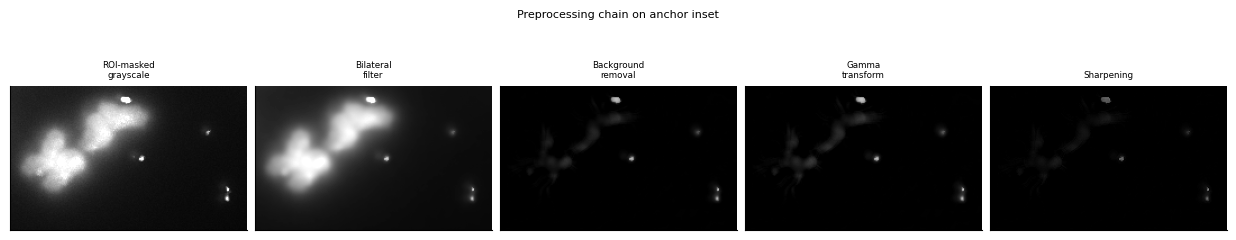

  Saved: fig3_preproc_steps.svg


In [5]:
# ── Fig 3B: Visualise preprocessing steps on anchor inset ───────────────────
x0, y0, x1, y1 = ANCHOR_INSET_BBOX

n_steps = len(intermediates)
fig, axes = plt.subplots(
    1, n_steps,
    figsize=(2.45 * n_steps, 2.7),
    constrained_layout=True,
)

if n_steps == 1:
    axes = [axes]

# Use a robust shared display range so contrast is comparable across panels.
all_pixels = np.concatenate([
    img[y0:y1, x0:x1].astype(float).ravel()
    for _, img in intermediates
])
vmin, vmax = np.percentile(all_pixels, [1, 99.7])

for ax, (label, img) in zip(axes, intermediates):
    crop = img[y0:y1, x0:x1]

    ax.imshow(crop, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(label, fontsize=6.3)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Preprocessing chain on anchor inset', y=1.05, fontsize=8)
display(fig)
save_fig(fig, 'fig3_preproc_steps')
plt.close(fig)

Other operators in the registry, such as CLAHE, sigmoid transform, and top-hat filtering, were considered during optimisation but were not selected for this anchor cell line.

### Full-frame context for the same chain

The composite below complements the inset-only view. The top row shows each preprocessing intermediate at full image resolution, with the inset rectangle drawn in white; the bottom row shows the matching crop. Full-frame and crop scaling are computed independently so each row uses the most informative dynamic range for that view.

Saved as: `fig3_preproc_steps_composite.svg`.


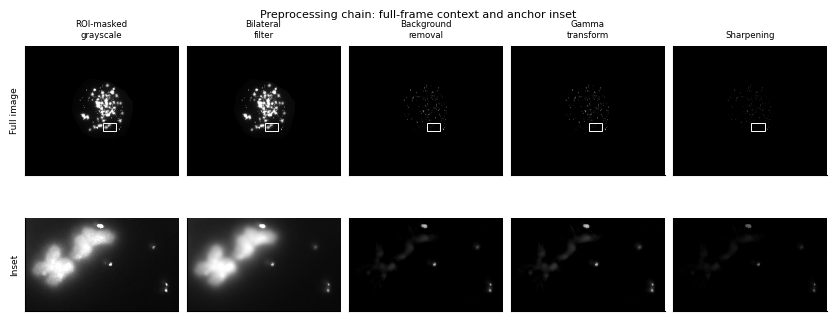

  Saved: fig3_preproc_steps_composite.svg


In [6]:
# ── Fig 3B: Full-frame + inset preprocessing composite ──────────────────────
# Top row: full-frame view, showing where the inset comes from.
# Bottom row: matched crop from the anchor inset, showing local ecDNA detail.

x0, y0, x1, y1 = ANCHOR_INSET_BBOX

# Use the same sequence as the inset-only figure:
# first ROI-masked grayscale, then each preprocessing output.
panels = intermediates
n_panels = len(panels)

fig, axes = plt.subplots(
    2, n_panels,
    figsize=(1.65 * n_panels, 3.25),
    constrained_layout=True,
)

if n_panels == 1:
    axes = np.array(axes).reshape(2, 1)

# Shared display scaling for full-frame grayscale panels.
# Percentiles are computed inside ROI only so zero background does not dominate.
roi_pixels = []
for _, img in panels:
    vals = img[anchor_roi_bin > 0].astype(float)
    if vals.size > 0:
        roi_pixels.append(vals)

all_roi_pixels = np.concatenate(roi_pixels)
full_vmin, full_vmax = np.percentile(all_roi_pixels, [1, 99.7])

# Separate crop scaling for the inset row, because the inset has a narrower
# intensity distribution and should show fine puncta clearly.
crop_pixels = np.concatenate([
    img[y0:y1, x0:x1].astype(float).ravel()
    for _, img in panels
])
crop_vmin, crop_vmax = np.percentile(crop_pixels, [1, 99.7])

for j, (label, img) in enumerate(panels):
    # Top row: full-frame image.
    ax_full = axes[0, j]
    ax_full.imshow(img, cmap='gray', vmin=full_vmin, vmax=full_vmax)

    # Draw inset location.
    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        fill=False,
        edgecolor='white',
        linewidth=0.7,
    )
    ax_full.add_patch(rect)

    ax_full.set_title(label, fontsize=6.2)
    ax_full.set_xticks([])
    ax_full.set_yticks([])

    # Bottom row: matching inset crop.
    ax_crop = axes[1, j]
    crop = img[y0:y1, x0:x1]
    ax_crop.imshow(crop, cmap='gray', vmin=crop_vmin, vmax=crop_vmax)
    ax_crop.set_xticks([])
    ax_crop.set_yticks([])

# Row labels on the left side.
axes[0, 0].set_ylabel('Full image', fontsize=6.5)
axes[1, 0].set_ylabel('Inset', fontsize=6.5)

fig.suptitle('Preprocessing chain: full-frame context and anchor inset', y=1.02, fontsize=8)

# Save panel source metadata.
pd.DataFrame({
    'panel_index': list(range(n_panels)),
    'label': [label.replace('\n', ' ') for label, _ in panels],
    'anchor_uid': ANCHOR_UID,
    'inset_x0': x0,
    'inset_y0': y0,
    'inset_x1': x1,
    'inset_y1': y1,
}).to_csv(
    OUT_DIR / 'fig3_preproc_steps_composite_source.csv',
    index=False,
)

display(fig)
save_fig(fig, 'fig3_preproc_steps_composite')
plt.close(fig)

## §4 — Detection and merge steps

After preprocessing, the classical pipeline binarises the enhanced grayscale image using an Otsu-derived threshold scaled by a cell-line-specific factor. The binary mask is morphologically closed, converted to connected components, and filtered by area to remove components that are too small or too large to represent ecDNA.

Two refinement steps then follow. First, nearby detections are merged when their centroids fall within the optimised merge distance. Second, each remaining object is labelled in HSV space to distinguish ecDNA-like puncta from chromosome-like signal. The panels below show these steps on the anchor image crop.

In [7]:
# ── §4: Run detection on the preprocessed anchor image ──────────────────────
from ecdna_bench.classical.detect import detect_objects, merge_close_objects, label_objects_hsv

# Apply the full preprocessing chain to get the final enhanced image
enhanced = apply_chain(gray_raw.copy(), combo, preproc_param_map)

# Extract detection params from frozen JSON
best_theta = anchor_opt['best_theta']
hsv_params = anchor_opt['fixed_hsv_params']

det_params = {
    'threshold_factor':   float(best_theta.get('threshold_factor', 1.0)),
    'morph_close_kernel': int(round(best_theta.get('morph_close_kernel', 3))),
    'min_area':           int(round(best_theta.get('min_area', 3))),
    'max_area':           int(round(best_theta.get('max_area', 500))),
}
merge_dist = float(best_theta.get('merge_distance', 5.0))

det_params_df = pd.DataFrame([
    {'parameter': 'threshold_factor',   'value': det_params['threshold_factor']},
    {'parameter': 'morph_close_kernel', 'value': det_params['morph_close_kernel']},
    {'parameter': 'min_area',           'value': det_params['min_area']},
    {'parameter': 'max_area',           'value': det_params['max_area']},
    {'parameter': 'merge_distance',     'value': merge_dist},
    {'parameter': 'white_value_threshold', 'value': hsv_params['white_value_threshold']},
    {'parameter': 'white_saturation_threshold', 'value': hsv_params['white_saturation_threshold']},
])

display(det_params_df)

det_params_df.to_csv(
    OUT_DIR / 'fig3_detection_steps_params_source.csv',
    index=False,
)

# Run detection pipeline
raw_objects = detect_objects(enhanced, **det_params)

merged_objects = merge_close_objects(
    raw_objects,
    merge_distance=merge_dist,
)

labelled_objects, _ = label_objects_hsv(
    merged_objects,
    rgb_masked,
    white_value_threshold=hsv_params['white_value_threshold'],
    white_saturation_threshold=hsv_params['white_saturation_threshold'],
)

ecdna_objects = [o for o in labelled_objects if o.get('label') == 'ecDNA']

print(f'Raw detected objects (after threshold + CC + size filter): {len(raw_objects)}')
print(f'After centroid-distance merge:                           {len(merged_objects)}')
print(f'After HSV filter:                                        {len(ecdna_objects)} ecDNA objects')

,parameter,value
0,threshold_factor,1.128032
1,morph_close_kernel,5.000000
2,min_area,9.000000
3,max_area,429.000000
4,merge_distance,8.191521
5,white_value_threshold,211.053982
6,white_saturation_threshold,27.606100


Raw detected objects (after threshold + CC + size filter): 96
After centroid-distance merge:                           96
After HSV filter:                                        96 ecDNA objects


### Detection and refinement on the anchor inset

The six panels below trace the detection sequence on an expanded crop around the anchor inset: enhanced grayscale → thresholded mask → size-filtered objects → morphological close → merged objects → HSV-filtered ecDNA detections. The number of objects retained at each stage is printed in the panel titles.

Saved as: `fig3_detection_steps.svg`. Detection parameters used are saved to `fig3_detection_steps_params_source.csv`.


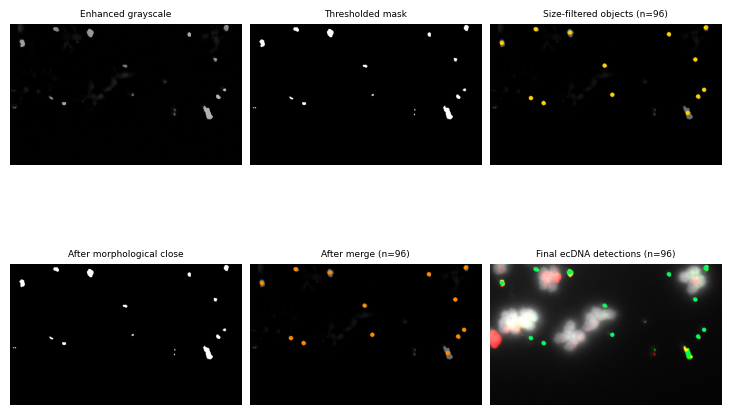

  Saved: fig3_detection_steps.svg


In [8]:
# ── Fig 3C: Detection and refinement steps visualised ───────────────────────
x0, y0, x1, y1 = ANCHOR_INSET_BBOX
cx, cy = (x0 + x1) // 2, (y0 + y1) // 2
hw, hh = (x1 - x0), (y1 - y0)

# Expanded crop around the anchor inset
ex0 = max(0, cx - hw)
ex1 = min(W, cx + hw)
ey0 = max(0, cy - hh)
ey1 = min(H, cy + hh)

# --- Reconstruct thresholding + morphological closing more faithfully ---
# Step 1: Otsu threshold value
otsu_thr, _ = cv2.threshold(
    enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Step 2: apply optimised threshold_factor
scaled_thr = otsu_thr * det_params['threshold_factor']
_, thr_bin = cv2.threshold(enhanced, scaled_thr, 255, cv2.THRESH_BINARY)
thr_bin = thr_bin.astype(np.uint8)

# Step 3: morphological closing with optimised kernel
k = det_params['morph_close_kernel']
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
closed_bin = cv2.morphologyEx(thr_bin, cv2.MORPH_CLOSE, kernel)
closed_bin = (closed_bin > 0).astype(np.uint8)

def overlay_objects_on_rgb(rgb, objects, color=(0, 255, 100), radius=4):
    out = rgb.copy()
    for obj in objects:
        cy, cx = obj['centroid']
        cv2.circle(out, (int(cx), int(cy)), radius, color, thickness=-1)
    return out

def overlay_objects_on_gray(gray, objects, color=(0, 255, 100), radius=4):
    base = cv2.cvtColor(gray.astype(np.uint8), cv2.COLOR_GRAY2RGB)
    for obj in objects:
        cy, cx = obj['centroid']
        cv2.circle(base, (int(cx), int(cy)), radius, color, thickness=-1)
    return base

# Crops
enhanced_crop = enhanced[ey0:ey1, ex0:ex1]
thr_crop = thr_bin[ey0:ey1, ex0:ex1]
closed_crop = closed_bin[ey0:ey1, ex0:ex1]

raw_overlay_crop = overlay_objects_on_gray(enhanced, raw_objects, color=(255, 210, 0))[ey0:ey1, ex0:ex1]
merged_overlay_crop = overlay_objects_on_gray(enhanced, merged_objects, color=(255, 140, 0))[ey0:ey1, ex0:ex1]
ecdna_overlay_crop = overlay_objects_on_rgb(rgb_masked, ecdna_objects, color=(0, 255, 100))[ey0:ey1, ex0:ex1]

fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.8), constrained_layout=True)

# Top row
axes[0, 0].imshow(enhanced_crop, cmap='gray')
axes[0, 0].set_title('Enhanced grayscale', fontsize=6.5)

axes[0, 1].imshow(thr_crop, cmap='gray')
axes[0, 1].set_title('Thresholded mask', fontsize=6.5)

axes[0, 2].imshow(raw_overlay_crop)
axes[0, 2].set_title(f'Size-filtered objects (n={len(raw_objects)})', fontsize=6.5)

# Bottom row
axes[1, 0].imshow(closed_crop, cmap='gray')
axes[1, 0].set_title('After morphological close', fontsize=6.5)

axes[1, 1].imshow(merged_overlay_crop)
axes[1, 1].set_title(f'After merge (n={len(merged_objects)})', fontsize=6.5)

axes[1, 2].imshow(ecdna_overlay_crop)
axes[1, 2].set_title(f'Final ecDNA detections (n={len(ecdna_objects)})', fontsize=6.5)

for ax in axes.ravel():
    ax.axis('off')

# Save compact source metadata
pd.DataFrame([
    {'stage': 'enhanced_grayscale', 'n_objects': np.nan},
    {'stage': 'thresholded_mask', 'n_objects': np.nan},
    {'stage': 'size_filtered_objects', 'n_objects': len(raw_objects)},
    {'stage': 'morphological_close', 'n_objects': np.nan},
    {'stage': 'merged_objects', 'n_objects': len(merged_objects)},
    {'stage': 'final_ecdna_objects', 'n_objects': len(ecdna_objects)},
]).to_csv(
    OUT_DIR / 'fig3_detection_steps_source.csv',
    index=False,
)

display(fig)
save_fig(fig, 'fig3_detection_steps')
plt.close(fig)

## §5 — Before vs after optimisation on the anchor image

We next compare the classical pipeline before and after Bayesian optimisation on the same anchor image. The "before BO" result uses the global default parameter set, whereas the "after BO" result uses the frozen NCI-H2170-specific parameter set selected by the optimisation procedure.

Predicted objects are matched to GS objects using the canonical evaluation settings: OR policy, `d_max = 20 px`, `IoU_min = 0.1`, and `α = 0.5`. The overlays use **green** for matched predictions (TP), **red** for unmatched predictions (FP), **magenta crosses** for unmatched GS (FN), and **yellow** for ignored redundant predictions if present.

**Headline numbers for this anchor image** (read directly from `fig3_before_after_bo_overlay_source.csv`):

| | n predicted | TP | FP | FN | F1 |
|---|---|---|---|---|---|
| Before BO | 45 | 44 | 1 | 72 | **0.547** |
| After BO  | 96 | 94 | 1 | 22 | **0.891** |

The HSV chromosome filter is so aggressive that both pipelines produce only one false positive — the cost is recall, which jumps from 38 % before BO to 81 % after BO. The aggregate (multi-image) version of this comparison is in §7.


### Run both pipelines on the anchor image

We now run the full classical pipeline twice on the anchor: once with the global default parameters (before BO) and once with the frozen NCI-H2170 parameters (after BO). Both runs share the same ROI-masked grayscale input. The output of each run is the list of HSV-classified ecDNA objects.


In [9]:
# ── §5: Before-vs-after BO inference on the anchor image ────────────────────
from ecdna_bench.classical.preprocess import default_chain
from ecdna_bench.evaluation.matching import match_objects
from ecdna_bench.evaluation.objects import objects_from_mask

def run_classical_object_pipeline(
    rgb_masked,
    enhanced_image,
    theta,
    hsv_params,
    label='pipeline',
):
    """Run detection, merge, HSV filtering and return ecDNA-labelled objects."""
    det_params_local = {
        'threshold_factor':   float(theta.get('threshold_factor', 1.0)),
        'morph_close_kernel': int(round(theta.get('morph_close_kernel', 3))),
        'min_area':           int(round(theta.get('min_area', 3))),
        'max_area':           int(round(theta.get('max_area', 500))),
    }
    merge_distance = float(theta.get('merge_distance', 5.0))

    raw = detect_objects(enhanced_image, **det_params_local)
    merged = merge_close_objects(raw, merge_distance=merge_distance)

    labelled, _ = label_objects_hsv(
        merged,
        rgb_masked,
        white_value_threshold=hsv_params['white_value_threshold'],
        white_saturation_threshold=hsv_params['white_saturation_threshold'],
    )

    ecdna = [o for o in labelled if o.get('label') == 'ecDNA']

    return {
        'label': label,
        'det_params': det_params_local,
        'merge_distance': merge_distance,
        'raw_objects': raw,
        'merged_objects': merged,
        'labelled_objects': labelled,
        'ecdna_objects': ecdna,
    }


# --- Before BO: global default pipeline ---
def_block = default_params['__global__']['default_before_opt']

def_chain_params = def_block['default_chain_params']
def_theta = def_block['best_theta']
def_hsv = def_block['fixed_hsv_params']

_, enhanced_default = default_chain(rgb_masked, def_chain_params)

default_run = run_classical_object_pipeline(
    rgb_masked=rgb_masked,
    enhanced_image=enhanced_default,
    theta=def_theta,
    hsv_params=def_hsv,
    label='Before BO',
)


# --- After BO: frozen NCI-H2170-specific pipeline ---
opt_run = run_classical_object_pipeline(
    rgb_masked=rgb_masked,
    enhanced_image=enhanced,
    theta=anchor_opt['best_theta'],
    hsv_params=anchor_opt['fixed_hsv_params'],
    label='After BO',
)

pred_default = default_run['ecdna_objects']
pred_opt = opt_run['ecdna_objects']

print(f"Before BO predicted objects: {len(pred_default)}")
print(f"After  BO predicted objects: {len(pred_opt)}")

Before BO predicted objects: 45
After  BO predicted objects: 96


### Match both predictions to GS under the canonical OR policy

The cell below matches each pipeline's predictions against the GS object set using the canonical evaluation parameters (`d_max = 20 px`, `IoU_min = 0.1`, `α = 0.5`, OR policy). It also reconstructs the matched / unmatched / ignored index sets so the next figure can colour each prediction by its outcome.


In [10]:
# ── Match before/after predictions against GS ───────────────────────────────
gt_objects = objects_from_mask(anchor_gt_bin, min_area=3)

MATCH_KWARGS = dict(
    max_dist=20,
    min_iou=0.1,
    alpha=0.5,
    policy='OR',
)

result_default = match_objects(pred_default, gt_objects, **MATCH_KWARGS)
result_opt = match_objects(pred_opt, gt_objects, **MATCH_KWARGS)


def metric_summary(match_result):
    """Return TP/FP/FN/F1/precision/recall from a MatchResult."""
    tp = int(match_result.tp)
    fp = int(match_result.fp)
    fn = int(match_result.fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0

    ignored = getattr(match_result, 'ignored', np.nan)
    try:
        ignored = int(ignored)
    except Exception:
        ignored = np.nan

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'ignored': ignored,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


def _as_index_set(x):
    """Convert list/array/set/tuple/None to a set of integer indices."""
    if x is None:
        return set()

    if isinstance(x, set):
        return {int(v) for v in x}

    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        out = set()
        for item in x:
            # Direct index
            if isinstance(item, (int, np.integer)):
                out.add(int(item))

            # Tuple/list pair or tuple/list with index first
            elif isinstance(item, (tuple, list)) and len(item) > 0:
                try:
                    out.add(int(item[0]))
                except Exception:
                    pass

            # Dict with possible index keys
            elif isinstance(item, dict):
                for key in ['idx', 'index', 'pred_idx', 'pred_index', 'gt_idx', 'gt_index']:
                    if key in item:
                        out.add(int(item[key]))
                        break

        return out

    return set()


def extract_match_sets(match_result, n_pred, n_gt):
    """
    Extract TP/FP/FN/ignored index sets from the current MatchResult API.

    Current observed attributes:
      matched
      unmatched_pred
      unmatched_gt
      ignored_pred
    """
    matched_pred = set()
    matched_gt = set()

    matched = getattr(match_result, 'matched', [])

    for item in matched:
        # Most likely: list of (pred_idx, gt_idx) tuples
        if isinstance(item, (tuple, list)) and len(item) >= 2:
            matched_pred.add(int(item[0]))
            matched_gt.add(int(item[1]))

        # Possible: dict records
        elif isinstance(item, dict):
            pi = item.get('pred_idx', item.get('pred_index', item.get('i', None)))
            gi = item.get('gt_idx', item.get('gt_index', item.get('j', None)))

            if pi is not None and gi is not None:
                matched_pred.add(int(pi))
                matched_gt.add(int(gi))

    unmatched_pred = _as_index_set(getattr(match_result, 'unmatched_pred', []))
    unmatched_gt = _as_index_set(getattr(match_result, 'unmatched_gt', []))
    ignored_pred = _as_index_set(getattr(match_result, 'ignored_pred', []))

    # Fallback consistency reconstruction.
    # If matched was parsed correctly, this should agree with match_result.tp.
    if len(matched_pred) != int(match_result.tp):
        print(
            f'Warning: parsed {len(matched_pred)} matched predictions, '
            f'but MatchResult.tp={match_result.tp}. Inspecting MatchResult.matched:'
        )
        print(match_result.matched[:5] if hasattr(match_result.matched, '__getitem__') else match_result.matched)

    # If unmatched sets are empty but FP/FN are nonzero, reconstruct by complement.
    if len(unmatched_pred) == 0 and int(match_result.fp) > 0:
        unmatched_pred = set(range(n_pred)) - matched_pred - ignored_pred

    if len(unmatched_gt) == 0 and int(match_result.fn) > 0:
        unmatched_gt = set(range(n_gt)) - matched_gt

    return {
        'matched_pred': matched_pred,
        'matched_gt': matched_gt,
        'unmatched_pred': unmatched_pred,
        'unmatched_gt': unmatched_gt,
        'ignored_pred': ignored_pred,
    }


sets_default = extract_match_sets(result_default, len(pred_default), len(gt_objects))
sets_opt = extract_match_sets(result_opt, len(pred_opt), len(gt_objects))

summary_rows = []

for name, pred_objs, result, sets in [
    ('Before BO', pred_default, result_default, sets_default),
    ('After BO', pred_opt, result_opt, sets_opt),
]:
    s = metric_summary(result)
    summary_rows.append({
        'condition': name,
        'n_pred': len(pred_objs),
        'n_gt': len(gt_objects),
        **s,
        'parsed_matched_pred': len(sets['matched_pred']),
        'parsed_unmatched_pred': len(sets['unmatched_pred']),
        'parsed_unmatched_gt': len(sets['unmatched_gt']),
        'parsed_ignored_pred': len(sets['ignored_pred']),
    })

bo_anchor_summary = pd.DataFrame(summary_rows)
display(bo_anchor_summary)

bo_anchor_summary.to_csv(
    OUT_DIR / 'fig3_before_after_bo_anchor_metrics_source.csv',
    index=False,
)

print(f"GS objects: {len(gt_objects)}")

,condition,n_pred,n_gt,tp,fp,fn,ignored,precision,recall,f1,parsed_matched_pred,parsed_unmatched_pred,parsed_unmatched_gt,parsed_ignored_pred
0,Before BO,45,116,44,1,72,0,0.977778,0.379310,0.546584,44,1,72,0
1,After BO,96,116,94,1,22,1,0.989474,0.810345,0.890995,94,1,22,1


GT objects: 116


### Before/after BO overlays — full image and inset

The 2×2 figure below combines a full-image and a zoomed-inset view of both pipelines' outputs. The white rectangle on the full-image panels marks the inset region.

Saved as: `fig3_before_after_bo_overlay.svg`. Per-image metrics are saved to `fig3_before_after_bo_overlay_source.csv`.


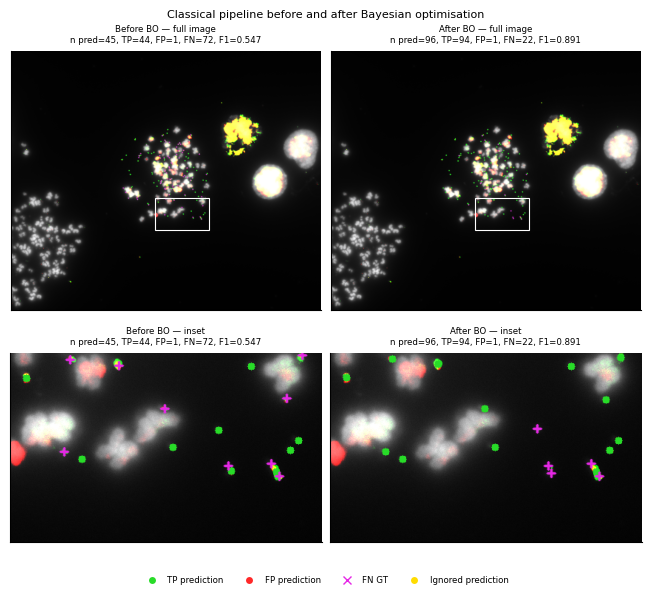

  Saved: fig3_before_after_bo_overlay.svg


In [11]:
# ── Fig 3D: Before vs after BO, full image + inset overlays ─────────────────

def draw_tpfpfn_overlay(
    rgb,
    pred_objs,
    gt_objs,
    match_sets,
    marker_radius=5,
    marker_thickness=-1,
    draw_gt_fn=True,
):
    """
    Overlay object-level matching outcomes.

    Green circle   = TP prediction
    Red circle     = FP prediction
    Yellow circle  = ignored prediction, if present
    Magenta cross  = FN gold-standard object
    """
    out = rgb.copy()

    matched_pred = match_sets['matched_pred']
    unmatched_pred = match_sets['unmatched_pred']
    ignored_pred = match_sets['ignored_pred']
    unmatched_gt = match_sets['unmatched_gt']

    # Draw predictions first.
    for i, obj in enumerate(pred_objs):
        cy, cx = obj['centroid']
        cx, cy = int(round(cx)), int(round(cy))

        if i in matched_pred:
            color = (40, 220, 40)      # green = TP
        elif i in ignored_pred:
            color = (255, 220, 0)      # yellow = ignored
        elif i in unmatched_pred:
            color = (255, 40, 40)      # red = FP
        else:
            color = (255, 220, 0)      # fallback = ignored/unknown

        cv2.circle(out, (cx, cy), marker_radius, color, marker_thickness)

    # Draw unmatched GS as crosses on top.
    if draw_gt_fn:
        for i in unmatched_gt:
            obj = gt_objs[i]
            cy, cx = obj['centroid']
            cx, cy = int(round(cx)), int(round(cy))
            cv2.drawMarker(
                out,
                (cx, cy),
                (230, 40, 230),        # magenta = FN
                markerType=cv2.MARKER_CROSS,
                markerSize=10,
                thickness=2,
                line_type=cv2.LINE_AA,
            )

    return out


overlay_default = draw_tpfpfn_overlay(
    anchor_rgb,
    pred_default,
    gt_objects,
    sets_default,
)

overlay_opt = draw_tpfpfn_overlay(
    anchor_rgb,
    pred_opt,
    gt_objects,
    sets_opt,
)

# Crop around the same expanded inset used earlier.
x0, y0, x1, y1 = ANCHOR_INSET_BBOX
cx, cy = (x0 + x1) // 2, (y0 + y1) // 2
hw, hh = (x1 - x0), (y1 - y0)

ex0 = max(0, cx - hw)
ex1 = min(W, cx + hw)
ey0 = max(0, cy - hh)
ey1 = min(H, cy + hh)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(6.4, 5.6),
    constrained_layout=True,
)

panels = [
    (axes[0, 0], overlay_default, 'Before BO — full image', result_default, len(pred_default)),
    (axes[0, 1], overlay_opt,     'After BO — full image',  result_opt,     len(pred_opt)),
    (axes[1, 0], overlay_default[ey0:ey1, ex0:ex1], 'Before BO — inset', result_default, len(pred_default)),
    (axes[1, 1], overlay_opt[ey0:ey1, ex0:ex1],     'After BO — inset',  result_opt,     len(pred_opt)),
]

for ax, img, title, res, n_pred in panels:
    s = metric_summary(res)

    ax.imshow(img)
    ax.set_title(
        f'{title}\n'
        f'n pred={n_pred}, TP={s["tp"]}, FP={s["fp"]}, FN={s["fn"]}, F1={s["f1"]:.3f}',
        fontsize=6.2,
    )
    ax.set_xticks([])
    ax.set_yticks([])

# Mark inset location on full-frame panels.
for ax in [axes[0, 0], axes[0, 1]]:
    rect = Rectangle(
        (ex0, ey0),
        ex1 - ex0,
        ey1 - ey0,
        fill=False,
        edgecolor='white',
        linewidth=0.8,
    )
    ax.add_patch(rect)

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=(40/255, 220/255, 40/255),
           markeredgecolor='none', markersize=5, label='TP prediction'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=(255/255, 40/255, 40/255),
           markeredgecolor='none', markersize=5, label='FP prediction'),
    Line2D([0], [0], marker='x', color=(230/255, 40/255, 230/255),
           markersize=6, linestyle='None', label='FN GS'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=(255/255, 220/255, 0/255),
           markeredgecolor='none', markersize=5, label='Ignored prediction'),
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=4,
    frameon=False,
    fontsize=6.2,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    'Classical pipeline before and after Bayesian optimisation',
    fontsize=8,
    y=1.02,
)

# Save source metadata.
pd.DataFrame([
    {
        'condition': 'Before BO',
        'anchor_uid': ANCHOR_UID,
        'n_gt': len(gt_objects),
        'n_pred': len(pred_default),
        **metric_summary(result_default),
        'inset_x0': ex0,
        'inset_y0': ey0,
        'inset_x1': ex1,
        'inset_y1': ey1,
    },
    {
        'condition': 'After BO',
        'anchor_uid': ANCHOR_UID,
        'n_gt': len(gt_objects),
        'n_pred': len(pred_opt),
        **metric_summary(result_opt),
        'inset_x0': ex0,
        'inset_y0': ey0,
        'inset_x1': ex1,
        'inset_y1': ey1,
    },
]).to_csv(
    OUT_DIR / 'fig3_before_after_bo_overlay_source.csv',
    index=False,
)

display(fig)
save_fig(fig, 'fig3_before_after_bo_overlay')
plt.close(fig)

## §6 — Bayesian optimisation trajectories

Stage 3 of the classical optimisation tunes the detection and merge parameters after fixing the preprocessing sequence and preprocessing parameters. Each partial CSV records one evaluated parameter configuration.

For readability, the figure below shows only the running best validation F1 across BO iterations. The marked point is the selected configuration for each cell line. Test F1, when present in the partial CSV, is reported only as a held-out estimate for the selected probe and is not used to interpret the trajectory.

In [12]:
# ── §6: Load Stage-3 BO partial CSVs ────────────────────────────────────────
# Path structure: outputs/classical_opt/partials/stage3/<CELLLINE>/<file>.csv

bo_data = {}

if BO_PARTIALS_DIR.exists():
    for cl_dir in sorted(BO_PARTIALS_DIR.iterdir()):
        if not cl_dir.is_dir():
            continue

        csvs = sorted(cl_dir.glob('*stage3_partial.csv'))
        if not csvs:
            csvs = sorted(cl_dir.glob('*.csv'))

        if not csvs:
            continue

        df = pd.read_csv(csvs[-1])

        cl_raw = cl_dir.name
        cl_disp = canonical_cell_line(cl_raw.replace('_', '-'))
        if cl_disp not in CL_ORDER:
            cl_disp = canonical_cell_line(cl_raw)

        bo_data[cl_disp] = df
        print(f'  Loaded {len(df)} BO probes for {cl_disp}: {csvs[-1].name}')
else:
    print(f'BO partials directory not found: {BO_PARTIALS_DIR}')
    print('Skipping BO trajectory plots.')

print(f'\nCell lines with BO data: {list(bo_data.keys())}')

  Loaded 51 BO probes for COLO320DM: COLO320DM__clahe__remove_background__apply_gamma__apply_sigmoid__stage3_partial.csv
  Loaded 51 BO probes for NCI-H2170: NCI_H2170__apply_bilateral_filter__remove_background__apply_gamma__apply_sharpening__stage3_partial.csv
  Loaded 51 BO probes for NCI-H716: NCI_H716__apply_gamma__remove_background__apply_sharpening__stage3_partial.csv
  Loaded 51 BO probes for SNU16: SNU16__clahe__remove_background__apply_gamma__apply_sigmoid__stage3_partial.csv

Cell lines with BO data: ['COLO320DM', 'NCI-H2170', 'NCI-H716', 'SNU16']


### Stage-3 BO convergence curves per cell line

For each of the four benchmark cell lines, the panel below plots the running best validation F1 as a function of BO iteration. The selected configuration (highest `val_f1`) is marked with a circle and the corresponding `val_f1` value is in the legend.

Saved as: `fig3_bo_trajectories_simplified.svg`. Full per-iteration trajectories are saved to `source_bo_trajectories.csv`; the selected probes are summarised in `source_bo_selected_probes.csv`.


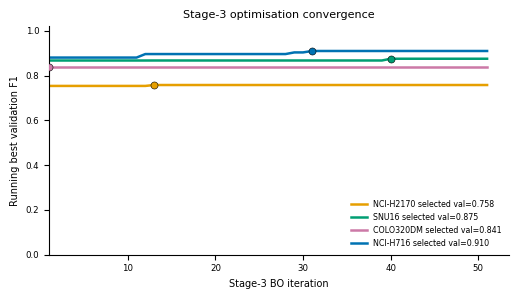

  Saved: fig3_bo_trajectories_simplified.svg


,cell_line,selected_iteration,selected_val_f1,selected_test_f1,n_probes
0,NCI-H2170,13,0.757946,0.740254,51
1,SNU16,40,0.875286,0.839161,51
2,COLO320DM,1,0.840611,0.827655,51
3,NCI-H716,31,0.909886,0.907822,51


  Source CSVs saved:
   - source_bo_trajectories.csv
   - source_bo_selected_probes.csv


In [13]:
# ── Fig 3E: Simplified Stage-3 BO convergence curves ────────────────────────
if bo_data:
    fig, ax = plt.subplots(figsize=(5.2, 3.0))

    bo_source_rows = []
    bo_selected_rows = []

    for cl in CL_ORDER:
        if cl not in bo_data:
            continue

        df = bo_data[cl].copy()

        if 'val_f1' not in df.columns:
            raise ValueError(
                f'{cl} BO partial CSV does not contain val_f1. '
                f'Available columns: {list(df.columns)}'
            )

        df['iteration'] = np.arange(1, len(df) + 1)
        df['running_best_val_f1'] = df['val_f1'].cummax()

        best_idx = df['val_f1'].idxmax()
        best_iter = int(df.loc[best_idx, 'iteration'])
        best_val = float(df.loc[best_idx, 'val_f1'])

        selected_test = (
            float(df.loc[best_idx, 'test_f1'])
            if 'test_f1' in df.columns and pd.notna(df.loc[best_idx, 'test_f1'])
            else np.nan
        )

        color = CELL_LINE_COLORS.get(cl, '#777777')

        # Running best only: cleaner than raw train/val scatter.
        ax.plot(
            df['iteration'],
            df['running_best_val_f1'],
            color=color,
            linewidth=1.8,
            label=f'{cl} selected val={best_val:.3f}',
        )

        # Selected point.
        ax.scatter(
            [best_iter],
            [best_val],
            color=color,
            s=26,
            edgecolor='black',
            linewidth=0.4,
            zorder=5,
        )

        bo_selected_rows.append({
            'cell_line': cl,
            'selected_iteration': best_iter,
            'selected_val_f1': best_val,
            'selected_test_f1': selected_test,
            'n_probes': len(df),
        })

        for _, row in df.iterrows():
            bo_source_rows.append({
                'cell_line': cl,
                'iteration': int(row['iteration']),
                'val_f1': float(row['val_f1']),
                'running_best_val_f1': float(row['running_best_val_f1']),
                'train_f1': float(row['train_f1']) if 'train_f1' in df.columns and pd.notna(row['train_f1']) else np.nan,
                'test_f1': float(row['test_f1']) if 'test_f1' in df.columns and pd.notna(row['test_f1']) else np.nan,
            })

    ax.set_xlabel('Stage-3 BO iteration')
    ax.set_ylabel('Running best validation F1')
    ax.set_ylim(0, 1.02)
    ax.set_xlim(left=1)
    ax.legend(
        frameon=False,
        fontsize=5.7,
        loc='lower right',
    )
    ax.set_title('Stage-3 optimisation convergence', fontsize=8)

    fig.tight_layout()
    display(fig)
    save_fig(fig, 'fig3_bo_trajectories_simplified')
    plt.close(fig)

    bo_source_df = pd.DataFrame(bo_source_rows)
    bo_selected_df = pd.DataFrame(bo_selected_rows)

    bo_source_df.to_csv(
        OUT_DIR / 'source_bo_trajectories.csv',
        index=False,
    )
    bo_selected_df.to_csv(
        OUT_DIR / 'source_bo_selected_probes.csv',
        index=False,
    )

    display(bo_selected_df)

    print('  Source CSVs saved:')
    print('   - source_bo_trajectories.csv')
    print('   - source_bo_selected_probes.csv')

else:
    print('No BO data available — skipping trajectory plot.')

## §7 — Before vs after BO: benchmark summary

To compare the default and optimised classical pipelines fairly, we ran a dedicated two-model benchmark containing only the pre-optimisation and post-optimisation classical masks. Both models were evaluated with the same matching framework used throughout the benchmark.

The panels below summarise the effect of optimisation under the OR matching criterion. We show (i) overall object-level precision, recall, and F1, (ii) F1 across train/validation/test splits, and (iii) F1 stratified by ecDNA count bin. The test split is not used for BO selection; it is shown here only for final reporting.

**Note on small differences from `SUBMISSION_PLAN.md`.** This notebook reports *pooled* per-cell-line F1 (TP, FP, FN summed within each cell line, then `F1 = 2TP / (2TP + FP + FN)`). `SUBMISSION_PLAN.md` quotes the BO-time `best_test_f1` recorded for the selected probe. The two quantities differ by ≤ 1 percentage point; both are correct, they are simply different aggregation choices.


### Load the two-model classical benchmark

We load `outputs/classical_bfr_aft/or_matching/per_image_metrics.csv`. This file contains exactly two models: the classical pipeline before BO (global defaults) and after BO (per-cell-line frozen parameters), each evaluated under the canonical OR matching policy on every benchmark image. Below we detect the model labels robustly and standardise them to `Classic (before opt)` and `Classic (after opt)` for plotting.


In [14]:
# ── §7: Load before-vs-after classical benchmark results ─────────────────────
CLASSICAL_BFR_AFT_DIR = REPO_ROOT / 'outputs' / 'classical_bfr_aft'
PER_IMAGE_BA_CSV = CLASSICAL_BFR_AFT_DIR / 'or_matching' / 'per_image_metrics.csv'

if not PER_IMAGE_BA_CSV.exists():
    raise FileNotFoundError(f'Could not find: {PER_IMAGE_BA_CSV}')

pim_ba = pd.read_csv(PER_IMAGE_BA_CSV)
pim_ba['cell_line'] = pim_ba['cell_line'].apply(canonical_cell_line)

print(f'Loaded: {PER_IMAGE_BA_CSV}')
print(f'Rows: {len(pim_ba):,}')
print('Models:')
for m in sorted(pim_ba['model'].dropna().unique()):
    print(f'  - {m}')

model_names = list(pim_ba['model'].dropna().unique())

# Robustly identify before/after model names.
after_candidates = [
    m for m in model_names
    if (
        ('classic' in str(m).lower() or 'classical' in str(m).lower())
        and (
            'after' in str(m).lower()
            or 'optim' in str(m).lower()
            or 'post' in str(m).lower()
            or str(m).lower() in {'classical', 'classic', 'classic_post_opt', 'classical_after_opt'}
        )
    )
]

before_candidates = [
    m for m in model_names
    if (
        ('classic' in str(m).lower() or 'classical' in str(m).lower())
        and (
            'before' in str(m).lower()
            or 'pre' in str(m).lower()
            or 'default' in str(m).lower()
            or str(m).lower() in {'classical_before_opt', 'classic_pre_opt', 'classical_pre_opt'}
        )
    )
]

if len(after_candidates) == 0:
    raise ValueError(f'Could not identify after-BO model. Available models: {model_names}')
if len(before_candidates) == 0:
    raise ValueError(f'Could not identify before-BO model. Available models: {model_names}')

after_model = after_candidates[0]
before_model = before_candidates[0]

print(f'\nBefore BO model: {before_model}')
print(f'After  BO model: {after_model}')

# Standardize labels for plotting.
label_map = {
    before_model: 'Classic (before opt)',
    after_model:  'Classic (after opt)',
}
pim_ba['model_plot'] = pim_ba['model'].map(label_map)

# Keep only these two models explicitly.
pim_ba = pim_ba[pim_ba['model_plot'].isin(['Classic (before opt)', 'Classic (after opt)'])].copy()

display(pim_ba.head())

Loaded: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/outputs/classical_bfr_aft/or_matching/per_image_metrics.csv
Rows: 2,290
Models:
  - Classic (after opt)
  - Classic (before opt)

Before BO model: Classic (before opt)
After  BO model: Classic (after opt)


,uid,split,cell_line,density_bin,model,pred_exists,gt_path,pred_path,obj_tp,obj_fp,...,pix_tn,pix_precision,pix_recall,pix_f1,pix_iou,pix_dice,cand_pairs,cand_preds,cand_gts,model_plot
0,colo320dm_qpcr_jq1_24h_ctrl_100,train,COLO320DM,50-149,Classic (after opt),1,/work/users/b/e/behnamie/ecDNA_Data/bioimage_a...,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...,57,4,...,5005020,0.054871,0.543346,0.099675,0.052452,0.099675,101,75,59,Classic (after opt)
1,colo320dm_qpcr_jq1_24h_ctrl_101,train,COLO320DM,10-49,Classic (after opt),1,/work/users/b/e/behnamie/ecDNA_Data/bioimage_a...,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...,35,5,...,5009636,0.081678,0.499145,0.140385,0.075491,0.140385,54,44,38,Classic (after opt)
2,colo320dm_qpcr_jq1_24h_ctrl_103,train,COLO320DM,10-49,Classic (after opt),1,/work/users/b/e/behnamie/ecDNA_Data/bioimage_a...,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...,38,3,...,5009248,0.077283,0.619329,0.137418,0.073778,0.137418,50,42,38,Classic (after opt)
3,colo320dm_qpcr_jq1_24h_ctrl_105,val,COLO320DM,50-149,Classic (after opt),1,/work/users/b/e/behnamie/ecDNA_Data/bioimage_a...,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...,53,8,...,5010008,0.142094,0.589309,0.228977,0.129291,0.228977,78,61,56,Classic (after opt)
4,colo320dm_qpcr_jq1_24h_ctrl_109,val,COLO320DM,50-149,Classic (after opt),1,/work/users/b/e/behnamie/ecDNA_Data/bioimage_a...,/proj/brunk_ecdna_cv_project/Poorya/ecdna-benc...,41,1,...,5009514,0.081462,0.294691,0.127640,0.068170,0.127640,73,52,44,Classic (after opt)


### Aggregation helpers

We define two small helpers used by the next cell. `aggregate_obj_metrics` sums per-image TP/FP/FN and computes pooled precision, recall, and F1; `aggregate_count_mae` averages the per-image absolute count error. These pooled (rather than image-averaged) metrics are the convention used throughout the benchmark.


In [15]:
# ── Helpers for aggregated metrics ────────────────────────────────────────────
DENSITY_BINS = [0, 10, 50, 150, 300, np.inf]
DENSITY_LABELS = ['0–9', '10–49', '50–149', '150–299', '300+']

def aggregate_obj_metrics(df):
    """Aggregate precision, recall, and F1 from per-image TP/FP/FN."""
    tp = df['obj_tp'].sum()
    fp = df['obj_fp'].sum()
    fn = df['obj_fn'].sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0

    return pd.Series({
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })

def aggregate_count_mae(df):
    """Aggregate MAE from per-image GT/pred counts."""
    # Try several likely column names to be robust.
    gt_candidates   = ['gt_count', 'count_gt', 'true_count', 'n_gt_objects']
    pred_candidates = ['pred_count', 'count_pred', 'predicted_count', 'n_pred_objects']

    gt_col = next((c for c in gt_candidates if c in df.columns), None)
    pred_col = next((c for c in pred_candidates if c in df.columns), None)

    if gt_col is None or pred_col is None:
        return np.nan

    return (df[pred_col] - df[gt_col]).abs().mean()

def get_gt_count_col(df):
    gt_candidates = ['gt_count', 'count_gt', 'true_count', 'n_gt_objects']
    gt_col = next((c for c in gt_candidates if c in df.columns), None)
    if gt_col is None:
        raise KeyError(
            f'Could not find GS count column. Available columns: {list(df.columns)}'
        )
    return gt_col

### Build the three summary tables

Three independent aggregations are built: (A) overall object-level metrics, (B) F1 per train/val/test split, and (C) F1 per ecDNA count bin. Each is saved to its own source-data CSV before the figure is drawn.


In [16]:
# ── Build summary tables for panel E-like figure ─────────────────────────────
# A) Overall object-level metrics
overall_rows = []
for model in ['Classic (before opt)', 'Classic (after opt)']:
    sub = pim_ba[pim_ba['model_plot'] == model]
    m = aggregate_obj_metrics(sub)
    overall_rows.append({
        'model': model,
        **m.to_dict(),
        'count_mae': aggregate_count_mae(sub),
    })

overall_df = pd.DataFrame(overall_rows)
display(overall_df)

# B) Split-wise F1
split_rows = []
for model in ['Classic (before opt)', 'Classic (after opt)']:
    for split in ['train', 'val', 'test']:
        sub = pim_ba[(pim_ba['model_plot'] == model) & (pim_ba['split'] == split)]
        if len(sub) == 0:
            continue
        m = aggregate_obj_metrics(sub)
        split_rows.append({
            'model': model,
            'split': split,
            'f1': m['f1'],
            'precision': m['precision'],
            'recall': m['recall'],
            'count_mae': aggregate_count_mae(sub),
            'n_images': len(sub),
        })

split_df = pd.DataFrame(split_rows)
display(split_df)

# C) Density-bin F1
gt_col = get_gt_count_col(pim_ba)
pim_ba['count_bin'] = pd.cut(
    pim_ba[gt_col],
    bins=DENSITY_BINS,
    labels=DENSITY_LABELS,
    right=False,
    include_lowest=True,
)

density_rows = []
for model in ['Classic (before opt)', 'Classic (after opt)']:
    for bin_label in DENSITY_LABELS:
        sub = pim_ba[(pim_ba['model_plot'] == model) & (pim_ba['count_bin'] == bin_label)]
        if len(sub) == 0:
            continue
        m = aggregate_obj_metrics(sub)
        density_rows.append({
            'model': model,
            'count_bin': bin_label,
            'f1': m['f1'],
            'precision': m['precision'],
            'recall': m['recall'],
            'count_mae': aggregate_count_mae(sub),
            'n_images': len(sub),
        })

density_df = pd.DataFrame(density_rows)
display(density_df)

# Save source data
overall_df.to_csv(OUT_DIR / 'source_fig3e_overall_metrics.csv', index=False)
split_df.to_csv(OUT_DIR / 'source_fig3e_split_metrics.csv', index=False)
density_df.to_csv(OUT_DIR / 'source_fig3e_density_metrics.csv', index=False)
print('  Source CSVs saved.')

,model,tp,fp,fn,precision,recall,f1,count_mae
0,Classic (before opt),57799.0,4779.0,170240.0,0.923631,0.253461,0.397768,144.157205
1,Classic (after opt),162540.0,27720.0,65499.0,0.854305,0.712773,0.777147,44.924017


,model,split,f1,precision,recall,count_mae,n_images
0,Classic (before opt),train,0.404242,0.925803,0.258572,145.808750,800
1,Classic (before opt),val,0.404109,0.924136,0.258594,135.894118,170
2,Classic (before opt),test,0.359457,0.911170,0.223891,144.634286,175
3,Classic (after opt),train,0.777134,0.856337,0.711342,46.405000,800
4,Classic (after opt),val,0.779759,0.865716,0.709331,42.052941,170
5,Classic (after opt),test,0.774773,0.834575,0.722969,40.942857,175


,model,count_bin,f1,precision,recall,count_mae,n_images
0,Classic (before opt),0–9,0.025316,0.021739,0.030303,7.000000,7
1,Classic (before opt),10–49,0.366334,0.773494,0.240000,23.126582,79
2,Classic (before opt),50–149,0.354534,0.865196,0.222946,73.580000,450
3,Classic (before opt),150–299,0.410391,0.927916,0.263455,152.277916,403
4,Classic (before opt),300+,0.407524,0.952133,0.259241,333.519417,206
5,Classic (after opt),0–9,0.142857,0.084746,0.454545,21.714286,7
6,Classic (after opt),10–49,0.740294,0.703978,0.780561,12.746835,79
7,Classic (after opt),50–149,0.735250,0.758076,0.713758,24.197778,450
8,Classic (after opt),150–299,0.788006,0.867052,0.722169,44.637717,403
9,Classic (after opt),300+,0.790618,0.904951,0.701935,103.888350,206


  Source CSVs saved.


### Three-panel before/after composite

The next cell renders the three aggregations in one paper-styled figure. Panel 1 shows precision / recall / F1; panel 2 shows F1 across train, val, and test; panel 3 shows F1 across count bins (`0–9, 10–49, 50–149, 150–299, 300+`). The annotation under each panel reports the absolute count MAE before and after BO.

Saved as: `fig3_bo_before_after_summary.svg`.


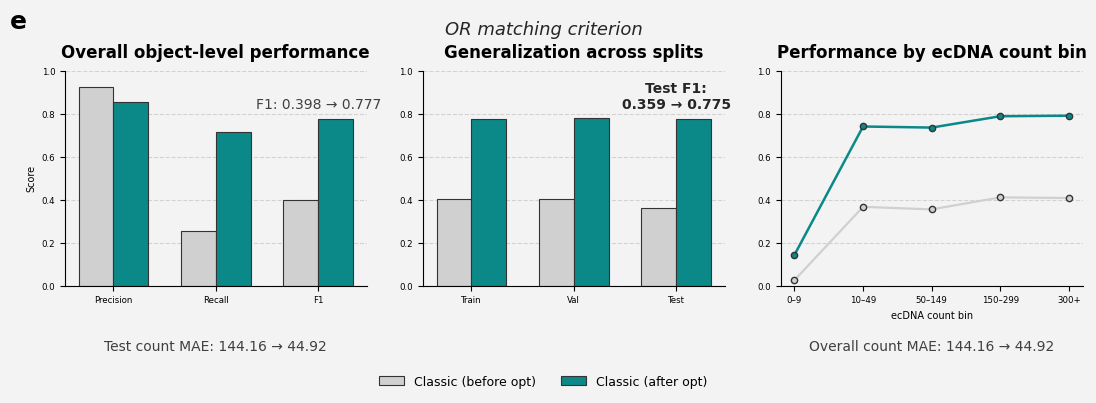

  Saved: fig3_bo_before_after_summary.svg


In [17]:
# ── Fig 3E: Before vs after BO summary (styled to match paper panel) ────────

before_color = '#D0D0D0'
after_color  = '#0B8888'
edge_color   = '#333333'
grid_color   = '#BDBDBD'
bg_color     = '#F3F3F3'

fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.1))
fig.patch.set_facecolor(bg_color)

for ax in axes:
    ax.set_facecolor(bg_color)

ax1, ax2, ax3 = axes

# -------------------------------------------------------------------------
# Extract rows
# -------------------------------------------------------------------------
overall_before = overall_df[overall_df['model'] == 'Classic (before opt)'].iloc[0]
overall_after  = overall_df[overall_df['model'] == 'Classic (after opt)'].iloc[0]

split_before = split_df[split_df['model'] == 'Classic (before opt)'].set_index('split')
split_after  = split_df[split_df['model'] == 'Classic (after opt)'].set_index('split')

density_before = density_df[density_df['model'] == 'Classic (before opt)'].set_index('count_bin')
density_after  = density_df[density_df['model'] == 'Classic (after opt)'].set_index('count_bin')

# If count bins are missing, preserve order safely
density_before = density_before.reindex(DENSITY_LABELS)
density_after  = density_after.reindex(DENSITY_LABELS)

# -------------------------------------------------------------------------
# Panel 1 — Overall object-level performance
# -------------------------------------------------------------------------
metric_order = ['precision', 'recall', 'f1']
metric_labels = ['Precision', 'Recall', 'F1']
x1 = np.arange(len(metric_order))
w = 0.34

vals_before = [overall_before[m] for m in metric_order]
vals_after  = [overall_after[m]  for m in metric_order]

ax1.bar(
    x1 - w/2, vals_before, width=w,
    color=before_color, edgecolor=edge_color, linewidth=0.8,
    label='Classic (before opt)'
)
ax1.bar(
    x1 + w/2, vals_after, width=w,
    color=after_color, edgecolor=edge_color, linewidth=0.8,
    label='Classic (after opt)'
)

ax1.set_xticks(x1)
ax1.set_xticklabels(metric_labels)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Score')
ax1.set_title('Overall object-level performance', fontsize=12, fontweight='bold', pad=10)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax1.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.6, color=grid_color)
ax1.set_axisbelow(True)

# Annotation above F1 bars
ax1.text(
    x1[2],
    max(vals_before[2], vals_after[2]) + 0.035,
    f'F1: {vals_before[2]:.3f} \u2192 {vals_after[2]:.3f}',
    ha='center',
    va='bottom',
    fontsize=10,
    color='0.25',
)

# Count MAE annotation below
if np.isfinite(overall_before['count_mae']) and np.isfinite(overall_after['count_mae']):
    ax1.text(
        0.5, -0.25,
        f'Test count MAE: {overall_before["count_mae"]:.2f} \u2192 {overall_after["count_mae"]:.2f}',
        transform=ax1.transAxes,
        ha='center',
        va='top',
        fontsize=10,
        color='0.25',
    )

# -------------------------------------------------------------------------
# Panel 2 — Generalization across splits
# -------------------------------------------------------------------------
split_order = ['train', 'val', 'test']
split_labels = ['Train', 'Val', 'Test']
x2 = np.arange(len(split_order))

before_split_vals = [split_before.loc[s, 'f1'] for s in split_order]
after_split_vals  = [split_after.loc[s, 'f1'] for s in split_order]

ax2.bar(
    x2 - w/2, before_split_vals, width=w,
    color=before_color, edgecolor=edge_color, linewidth=0.8
)
ax2.bar(
    x2 + w/2, after_split_vals, width=w,
    color=after_color, edgecolor=edge_color, linewidth=0.8
)

ax2.set_xticks(x2)
ax2.set_xticklabels(split_labels)
ax2.set_ylim(0, 1.0)
ax2.set_title('Generalization across splits', fontsize=12, fontweight='bold', pad=10)
ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax2.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.6, color=grid_color)
ax2.set_axisbelow(True)

# Test F1 annotation
test_before = before_split_vals[2]
test_after  = after_split_vals[2]

ax2.text(
    x2[2],
    max(test_before, test_after) + 0.035,
    f'Test F1:\n{test_before:.3f} \u2192 {test_after:.3f}',
    ha='center',
    va='bottom',
    fontsize=10,
    color='0.15',
    fontweight='bold',
)

# -------------------------------------------------------------------------
# Panel 3 — Performance by ecDNA count bin
# -------------------------------------------------------------------------
x3 = np.arange(len(DENSITY_LABELS))

ax3.plot(
    x3,
    density_before['f1'].values,
    marker='o',
    markersize=4.5,
    color=before_color,
    markeredgecolor=edge_color,
    linewidth=1.6,
    label='Classic (before opt)',
)
ax3.plot(
    x3,
    density_after['f1'].values,
    marker='o',
    markersize=4.5,
    color=after_color,
    markeredgecolor=edge_color,
    linewidth=1.8,
    label='Classic (after opt)',
)

ax3.set_xticks(x3)
ax3.set_xticklabels(DENSITY_LABELS)
ax3.set_ylim(0, 1.0)
ax3.set_title('Performance by ecDNA count bin', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('ecDNA count bin')
ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax3.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.6, color=grid_color)
ax3.set_axisbelow(True)

if np.isfinite(overall_before['count_mae']) and np.isfinite(overall_after['count_mae']):
    ax3.text(
        0.5, -0.25,
        f'Overall count MAE: {overall_before["count_mae"]:.2f} \u2192 {overall_after["count_mae"]:.2f}',
        transform=ax3.transAxes,
        ha='center',
        va='top',
        fontsize=10,
        color='0.25',
    )

# -------------------------------------------------------------------------
# Shared figure annotations
# -------------------------------------------------------------------------
# Panel label
fig.text(0.015, 0.96, 'e', fontsize=18, fontweight='bold')

# Top centered italic heading
fig.text(
    0.5, 0.98, 'OR matching criterion',
    ha='center', va='top',
    fontsize=13, fontstyle='italic', color='0.15'
)

# Shared legend
legend_handles = [
    Rectangle((0, 0), 1, 1, facecolor=before_color, edgecolor=edge_color, linewidth=0.8),
    Rectangle((0, 0), 1, 1, facecolor=after_color, edgecolor=edge_color, linewidth=0.8),
]

fig.legend(
    legend_handles,
    ['Classic (before opt)', 'Classic (after opt)'],
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 0.055),
)

fig.tight_layout(rect=[0.02, 0.08, 1.0, 0.95])
display(fig)
save_fig(fig, 'fig3_bo_before_after_summary')
plt.close(fig)

### Test-split F1 by cell line

The companion panel breaks the test-split F1 down by cell line. For each cell line we plot F1 before BO (light grey) next to F1 after BO (teal), with a thin connector line emphasising the paired comparison and a `Δ` annotation above each pair. This panel uses only the held-out test split (175 images).

Saved as: `fig3_before_after_f1_by_cell_line.svg`. Per-cell-line aggregation is saved to `source_before_after_f1_by_cell_line.csv`.


Loaded: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/outputs/classical_bfr_aft/or_matching/per_image_metrics.csv
Rows: 2,290
Models:
  - Classic (after opt)
  - Classic (before opt)

Before BO model: Classic (before opt)
After  BO model: Classic (after opt)


,model,cell_line,n_images,tp,fp,fn,precision,recall,f1,count_mae,condition
1,Classic (after opt),NCI-H2170,134.0,18348.0,4108.0,8042.0,0.817064,0.695263,0.751259,44.000000,After BO
5,Classic (before opt),NCI-H2170,134.0,5410.0,523.0,20980.0,0.911849,0.205002,0.334746,152.283582,Before BO
3,Classic (after opt),SNU16,19.0,4095.0,573.0,929.0,0.877249,0.815088,0.845027,53.000000,After BO
7,Classic (before opt),SNU16,19.0,1394.0,118.0,3630.0,0.921958,0.277468,0.426561,184.421053,Before BO
0,Classic (after opt),COLO320DM,11.0,409.0,71.0,103.0,0.852083,0.798828,0.824597,10.181818,After BO
4,Classic (before opt),COLO320DM,11.0,106.0,27.0,406.0,0.796992,0.207031,0.328682,36.181818,Before BO
2,Classic (after opt),NCI-H716,11.0,1460.0,67.0,242.0,0.956123,0.857814,0.904305,13.636364,After BO
6,Classic (before opt),NCI-H716,11.0,619.0,66.0,1083.0,0.903650,0.363690,0.518643,91.181818,Before BO


  Source CSV saved.


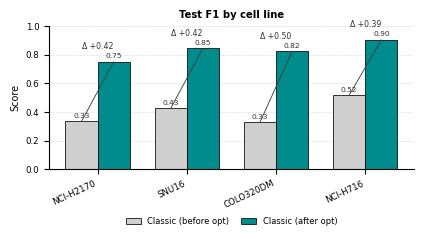

  Saved: fig3_before_after_f1_by_cell_line.svg


In [18]:
# ── Fig 3F: Before vs after BO by cell line — paper-matched style ───────────
# Self-contained: loads the two-model classical benchmark and builds the table.

CLASSICAL_BFR_AFT_CSV = (
    REPO_ROOT / 'outputs' / 'classical_bfr_aft' / 'or_matching' / 'per_image_metrics.csv'
)

if not CLASSICAL_BFR_AFT_CSV.exists():
    raise FileNotFoundError(
        f'Could not find: {CLASSICAL_BFR_AFT_CSV}\n'
        'Run:\n'
        'python -m ecdna_bench.cli.benchmark \\\n'
        '    --config configs/default.yaml \\\n'
        '    --models classical classical_before_opt \\\n'
        '    --skip-harmonize \\\n'
        '    --output-dir outputs/classical_bfr_aft'
    )

pim_ba = pd.read_csv(CLASSICAL_BFR_AFT_CSV)
pim_ba['cell_line'] = pim_ba['cell_line'].apply(canonical_cell_line)

print(f'Loaded: {CLASSICAL_BFR_AFT_CSV}')
print(f'Rows: {len(pim_ba):,}')
print('Models:')
for m in sorted(pim_ba['model'].dropna().unique()):
    print(f'  - {m}')

# Detect model names robustly.
model_names = list(pim_ba['model'].dropna().unique())

before_model = next(
    (m for m in model_names if 'before' in str(m).lower()),
    None,
)
after_model = next(
    (m for m in model_names if 'after' in str(m).lower()),
    None,
)

if before_model is None or after_model is None:
    raise ValueError(
        'Could not identify before/after classical models.\n'
        f'Available models: {model_names}'
    )

print(f'\nBefore BO model: {before_model}')
print(f'After  BO model: {after_model}')


def aggregate_object_metrics(df):
    """Aggregate object metrics by summing TP/FP/FN across images."""
    tp = float(df['obj_tp'].sum())
    fp = float(df['obj_fp'].sum())
    fn = float(df['obj_fn'].sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0

    count_mae = (
        df['count_abs_error'].mean()
        if 'count_abs_error' in df.columns
        else np.nan
    )

    return pd.Series({
        'n_images': len(df),
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'count_mae': count_mae,
    })


# Build per-cell-line summary on held-out test split only.
test_df = pim_ba[pim_ba['split'] == 'test'].copy()

before_after_cell_df = (
    test_df
    .groupby(['model', 'cell_line'], observed=True)
    .apply(aggregate_object_metrics)
    .reset_index()
)

before_after_cell_df['condition'] = np.where(
    before_after_cell_df['model'] == before_model,
    'Before BO',
    'After BO',
)

# Keep canonical cell-line order.
before_after_cell_df['cell_line'] = pd.Categorical(
    before_after_cell_df['cell_line'],
    categories=CL_ORDER,
    ordered=True,
)
before_after_cell_df = before_after_cell_df.sort_values(['cell_line', 'condition'])

display(before_after_cell_df)

before_after_cell_df.to_csv(
    OUT_DIR / 'source_before_after_f1_by_cell_line.csv',
    index=False,
)
print('  Source CSV saved.')


# ── Plot: same visual language as attached Figure 3 panel ───────────────────
plot_df = before_after_cell_df.copy()

before_df = (
    plot_df[plot_df['model'] == before_model]
    .set_index('cell_line')
    .reindex(CL_ORDER)
)

after_df = (
    plot_df[plot_df['model'] == after_model]
    .set_index('cell_line')
    .reindex(CL_ORDER)
)

cls_plot = [
    cl for cl in CL_ORDER
    if cl in before_df.index
    and cl in after_df.index
    and pd.notna(before_df.loc[cl, 'f1'])
    and pd.notna(after_df.loc[cl, 'f1'])
]

x = np.arange(len(cls_plot))
width = 0.36

before_vals = np.array([before_df.loc[cl, 'f1'] for cl in cls_plot], dtype=float)
after_vals  = np.array([after_df.loc[cl,  'f1'] for cl in cls_plot], dtype=float)
delta_vals  = after_vals - before_vals

fig, ax = plt.subplots(figsize=(4.25, 2.55))

# Match the attached panel: light gray before, teal after.
before_color = '#CFCFCF'
after_color  = '#008C8C'

bars_before = ax.bar(
    x - width / 2,
    before_vals,
    width,
    color=before_color,
    edgecolor='black',
    linewidth=0.55,
    label='Classic (before opt)',
)

bars_after = ax.bar(
    x + width / 2,
    after_vals,
    width,
    color=after_color,
    edgecolor='black',
    linewidth=0.55,
    label='Classic (after opt)',
)

# Thin connector lines emphasize paired comparison.
for i in range(len(cls_plot)):
    ax.plot(
        [x[i] - width / 2, x[i] + width / 2],
        [before_vals[i], after_vals[i]],
        color='0.25',
        linewidth=0.65,
        zorder=4,
    )

# Bar-value labels, compact and journal-style.
for bar, val in zip(bars_before, before_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.018,
        f'{val:.2f}',
        ha='center',
        va='bottom',
        fontsize=5.4,
        color='0.20',
    )

for bar, val in zip(bars_after, after_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.018,
        f'{val:.2f}',
        ha='center',
        va='bottom',
        fontsize=5.4,
        color='0.20',
    )

# Delta annotation above each pair.
for i, d in enumerate(delta_vals):
    y = max(before_vals[i], after_vals[i]) + 0.075
    ax.text(
        x[i],
        y,
        f'Δ {d:+.2f}',
        ha='center',
        va='bottom',
        fontsize=5.6,
        color='0.20',
    )

ax.set_title('Test F1 by cell line', fontsize=7.2, fontweight='bold', pad=6)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)

ax.set_xticks(x)
ax.set_xticklabels(cls_plot, rotation=25, ha='right')

ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(axis='y', linestyle='--', linewidth=0.45, alpha=0.45)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend below, matching the attached composite-panel style.
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    ncol=2,
    frameon=False,
    fontsize=6.0,
    handlelength=1.8,
    columnspacing=1.4,
)

fig.tight_layout()
display(fig)
save_fig(fig, 'fig3_before_after_f1_by_cell_line')
plt.close(fig)

## §8 — Frozen parameter table

The table below summarizes the final frozen classical parameters for the four benchmark cell lines. These values are read directly from `stage3_frozen_params.json` and are the parameters used to generate the optimized classical predictions.

Each row represents one cell line. The configuration was selected using validation F1. The held-out test F1 is shown only as post-freezing performance, not as a selection criterion.

In [19]:
# ── §8: Build frozen parameter table (full source table) ─────────────────────
from matplotlib import colors as mcolors

param_rows = []

for cl in CL_ORDER:
    block = frozen_params.get(cl, {})

    if not block:
        raise KeyError(
            f'{cl} is missing from frozen parameter JSON: {FROZEN_PARAMS_JSON}'
        )

    if len(block) != 1:
        print(f'Warning: expected one frozen combo for {cl}, found {len(block)}. Using the first.')

    combo_id = next(iter(block))
    p = block[combo_id]
    theta = p.get('best_theta', {})

    required_theta_keys = [
        'threshold_factor',
        'morph_close_kernel',
        'min_area',
        'max_area',
        'merge_distance',
    ]

    missing_theta = [k for k in required_theta_keys if k not in theta]
    if missing_theta:
        raise KeyError(f'Missing detection parameters for {cl}: {missing_theta}')

    if 'best_val_f1' not in p:
        raise KeyError(
            f'{cl} frozen parameter block is missing best_val_f1. '
            'Selection should be validation-based.'
        )

    hsv = p.get('fixed_hsv_params', {})

    row = {
        'cell_line': cl,
        'combo_id': combo_id,
        'preprocessing_combo': ' → '.join(p.get('combo', [])),
        'threshold_factor': round(float(theta['threshold_factor']), 3),
        'morph_close_kernel': int(round(theta['morph_close_kernel'])),
        'min_area_px': int(round(theta['min_area'])),
        'max_area_px': int(round(theta['max_area'])),
        'merge_distance_px': round(float(theta['merge_distance']), 2),
        'selected_val_f1': round(float(p['best_val_f1']), 4),
        'heldout_test_f1': round(float(p.get('best_test_f1', np.nan)), 4),
        'white_value_threshold': hsv.get('white_value_threshold', np.nan),
        'white_saturation_threshold': hsv.get('white_saturation_threshold', np.nan),
    }

    param_rows.append(row)

param_df = pd.DataFrame(param_rows)

display(param_df)

param_df.to_csv(
    OUT_DIR / 'source_frozen_params_table.csv',
    index=False,
)

print('  Source CSV saved.')

,cell_line,combo_id,preprocessing_combo,threshold_factor,morph_close_kernel,min_area_px,max_area_px,merge_distance_px,selected_val_f1,heldout_test_f1,white_value_threshold,white_saturation_threshold
0,NCI-H2170,apply_bilateral_filter__remove_background__app...,apply_bilateral_filter → remove_background → a...,1.128,5,9,429,8.19,0.7579,0.7403,211.053982,27.606100
1,SNU16,clahe__remove_background__apply_gamma__apply_s...,clahe → remove_background → apply_gamma → appl...,1.600,1,1,396,3.98,0.8753,0.8392,198.819720,30.311628
2,COLO320DM,clahe__remove_background__apply_gamma__apply_s...,clahe → remove_background → apply_gamma → appl...,1.000,5,3,900,5.00,0.8406,0.8277,190.537475,20.515355
3,NCI-H716,apply_gamma__remove_background__apply_sharpening,apply_gamma → remove_background → apply_sharpe...,1.600,5,1,906,3.32,0.9099,0.9078,201.561038,14.783427


  Source CSV saved.


### Render the frozen-parameter table as a figure

The next cell renders the same table as a publication-ready figure: rows are colour-tinted by cell line, the preprocessing combo column is left-aligned and word-wrapped, and the held-out test F1 column appears alongside the selected validation F1.

Saved as: `fig3_frozen_params_table.svg`. The full row data (including HSV thresholds) is saved to `source_frozen_params_table.csv`.


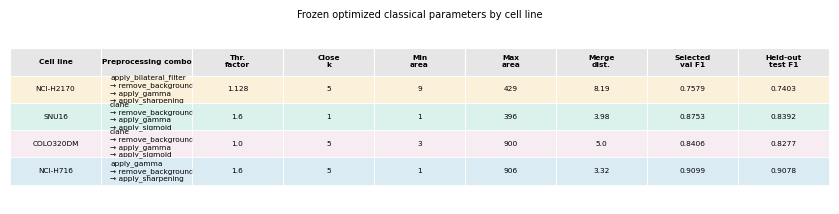

  Saved: fig3_frozen_params_table.svg


In [20]:
# ── Fig 3G: Frozen parameter table as compact figure ─────────────────────────
table_df = param_df.copy()

# Wrap long preprocessing combos to improve readability.
table_df['preprocessing_combo_wrapped'] = (
    table_df['preprocessing_combo']
    .str.replace(' → ', '\n→ ', regex=False)
)

# Keep the displayed figure compact.
display_cols = [
    'cell_line',
    'preprocessing_combo_wrapped',
    'threshold_factor',
    'morph_close_kernel',
    'min_area_px',
    'max_area_px',
    'merge_distance_px',
    'selected_val_f1',
    'heldout_test_f1',
]

col_labels = [
    'Cell line',
    'Preprocessing combo',
    'Thr.\nfactor',
    'Close\nk',
    'Min\narea',
    'Max\narea',
    'Merge\ndist.',
    'Selected\nval F1',
    'Held-out\ntest F1',
]

table_data = table_df[display_cols].values.tolist()

fig, ax = plt.subplots(figsize=(8.4, 2.15))
ax.axis('off')

tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(5.3)
tbl.scale(1.0, 1.55)

# Header styling
for j in range(len(col_labels)):
    cell = tbl[0, j]
    cell.set_facecolor('#E6E6E6')
    cell.set_text_props(fontweight='bold', color='black')
    cell.set_edgecolor('white')
    cell.set_linewidth(0.8)

# Row styling
for i, cl in enumerate(table_df['cell_line'], start=1):
    base_color = CELL_LINE_COLORS.get(cl, '#FFFFFF')
    rgba = mcolors.to_rgba(base_color, alpha=0.14)

    for j in range(len(col_labels)):
        cell = tbl[i, j]
        cell.set_facecolor(rgba)
        cell.set_edgecolor('white')
        cell.set_linewidth(0.6)

# Left-align the preprocessing combo column
combo_col_idx = display_cols.index('preprocessing_combo_wrapped')
for i in range(1, len(table_df) + 1):
    tbl[i, combo_col_idx].get_text().set_ha('left')

ax.set_title(
    'Frozen optimized classical parameters by cell line',
    fontsize=7.1,
    pad=8,
)

fig.tight_layout()
display(fig)
save_fig(fig, 'fig3_frozen_params_table')
plt.close(fig)

---

## §9 — Saved figures and source data

The cell below lists every file the notebook just produced under `release/figures/notebook02/`. Each quantitative panel has an accompanying source-data CSV so a reviewer can reproduce any number in the figures from a single file.


In [21]:
# ── Notebook 02 output manifest ─────────────────────────────────────────────
generated_files = sorted(
    [
        p for p in OUT_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in {'.svg', '.png', '.csv'}
    ],
    key=lambda p: (p.suffix.lower(), p.name),
)

if not generated_files:
    print(f'No files found in {OUT_DIR}')
else:
    manifest_rows = [
        {
            'file': p.name,
            'type': p.suffix.lower().lstrip('.'),
            'size_kb': round(p.stat().st_size / 1024, 1),
        }
        for p in generated_files
    ]

    output_manifest = pd.DataFrame(manifest_rows)
    display(output_manifest)

    manifest_csv = OUT_DIR / 'notebook02_output_manifest.csv'
    output_manifest.to_csv(manifest_csv, index=False)

    print(f'Output directory: {OUT_DIR}')
    print(f'Files written:    {len(output_manifest):,}')
    print(f'Manifest saved:   {manifest_csv}')


,file,type,size_kb
0,fig3_before_after_bo_anchor_metrics_source.csv,csv,0.3
1,fig3_before_after_bo_overlay_source.csv,csv,0.4
2,fig3_detection_steps_params_source.csv,csv,0.2
3,fig3_detection_steps_source.csv,csv,0.1
4,fig3_pipeline_schematic_source.csv,csv,0.4
5,fig3_preproc_steps_composite_source.csv,csv,0.4
6,fig3_preproc_steps_params_source.csv,csv,0.3
7,notebook02_output_manifest.csv,csv,1.3
8,source_before_after_f1_by_cell_line.csv,csv,1.1
9,source_bo_selected_probes.csv,csv,0.3


Output directory: /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook02
Files written:    33
Manifest saved:   /proj/brunk_ecdna_cv_project/Poorya/ecdna-bench/release/figures/notebook02/notebook02_output_manifest.csv
